In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Loan_default.csv")
df


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


### 1 remove duplicate rows

In [3]:
print(df.duplicated().sum()) #check how many dupicate
df.drop_duplicates(inplace=True)

0


### 2 count missing value

In [4]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

### 3 handel missing value(remove rows) use when very few raws have missing values(<5%)

In [5]:
df.dropna(inplace=True)

### 4 remove column use when whole column is empty(>50%)

In [6]:
df.drop(columns=["Age"], inplace=True)

### 5 histogram(numeric columns)

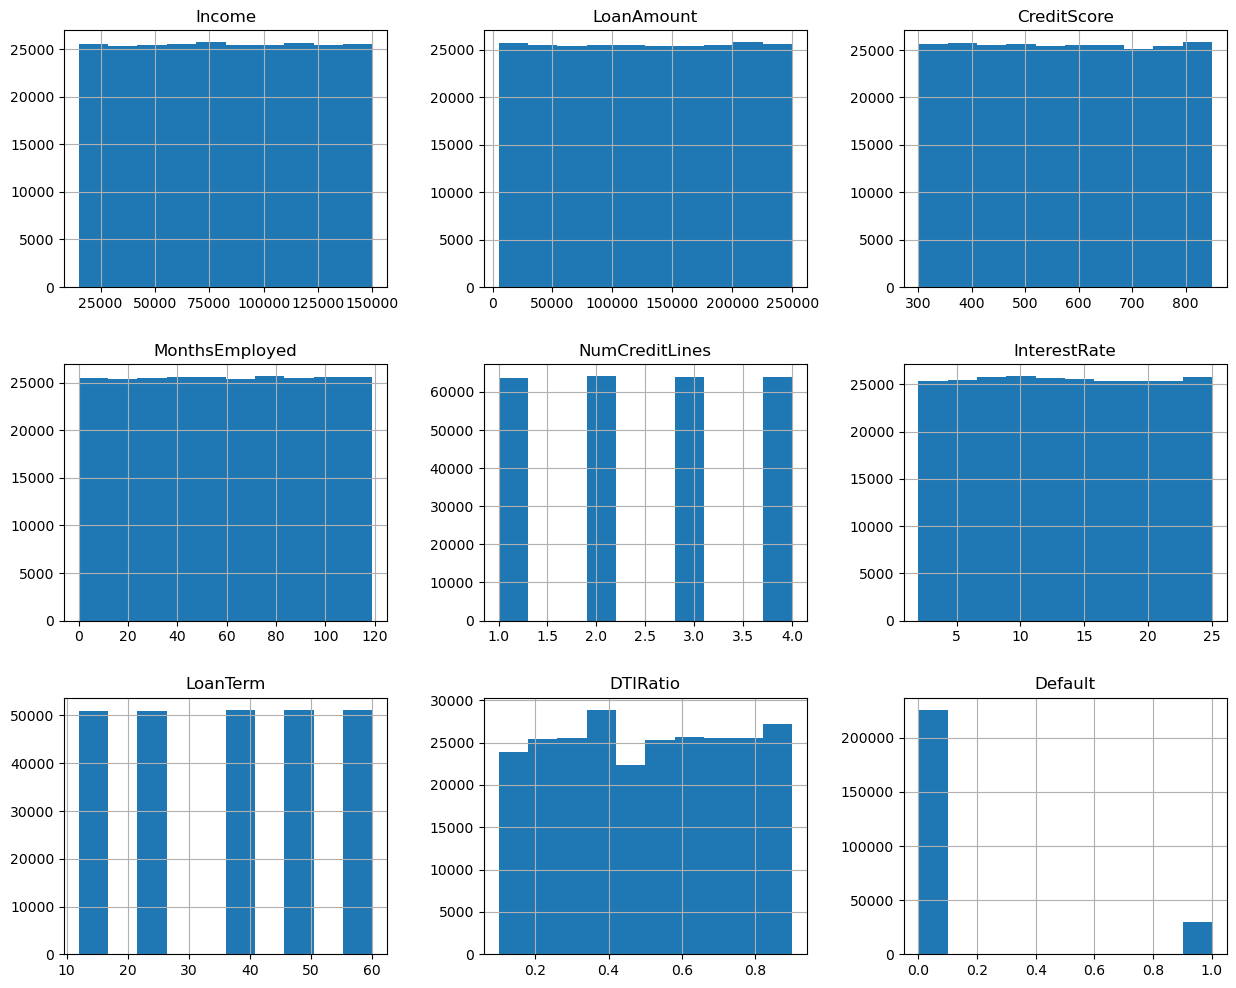

In [7]:
df.hist(figsize=(15,12))
plt.show()

### 6 Box plot

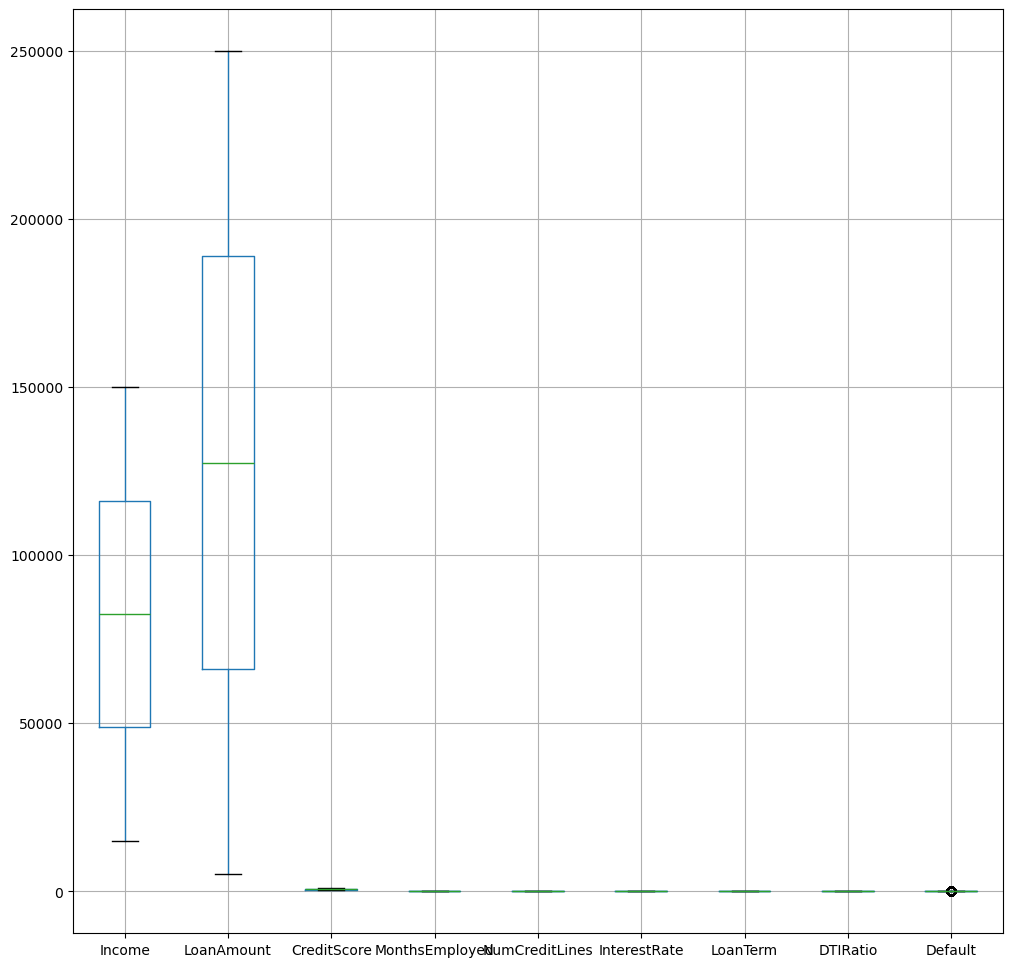

In [8]:
df.boxplot(figsize=(12,12))
plt.show()

### 7 Bar char (category column)

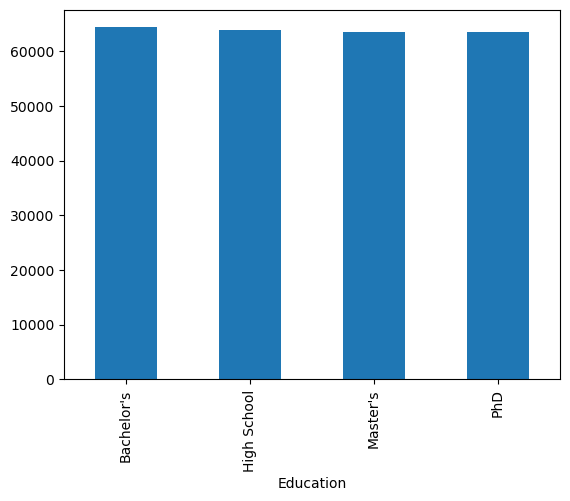

In [9]:
df["Education"].value_counts().plot(kind="bar")
plt.show()


### 8 pie chart 

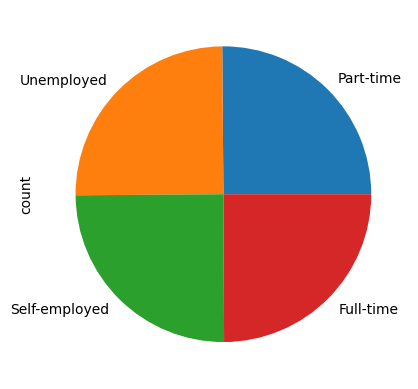

In [10]:
df["EmploymentType"].value_counts().plot(kind="pie")
plt.show()

### 9 fix datatype(Convert to float)

In [11]:
df["LoanAmount"] = df["LoanAmount"].astype(float)
df.dtypes

LoanID             object
Income              int64
LoanAmount        float64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

### 10  Detect and Handle Outliers (IQR Method)

In [12]:
Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['LoanAmount'] >= lower) & (df['LoanAmount'] <= upper)]

### 11 Encode Categorical Column (converts text (categorical) data into numbers so that a machine learning model can understand it.)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])

print(df[['Education']])

        Education
0               0
1               2
2               2
3               1
4               0
...           ...
255342          0
255343          1
255344          1
255345          1
255346          0

[255347 rows x 1 columns]


### 12 Cleaned messy column names

In [14]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

Index(['loanid', 'income', 'loanamount', 'creditscore', 'monthsemployed',
       'numcreditlines', 'interestrate', 'loanterm', 'dtiratio', 'education',
       'employmenttype', 'maritalstatus', 'hasmortgage', 'hasdependents',
       'loanpurpose', 'hascosigner', 'default'],
      dtype='object')


### 13 Scaled numeric columns

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Age', 'LoanAmount']] = scaler.fit_transform(df[['Age', 'LoanAmount']])

print(df[['Age', 'LoanAmount']])

KeyError: "None of [Index(['Age', 'LoanAmount'], dtype='object')] are in the [columns]"